In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# ==========================================
# 1. GENERATE THE RAW MULTI-TENANT LOG FILE
# ==========================================
np.random.seed(42)
num_records = 1000
tenants = ['Acme_Corp', 'Beta_Industries', 'Delta_Systems', 'Omega_Labs']
tiers = ['Basic', 'Professional', 'Enterprise']
statuses = ['Active', 'Active', 'Active', 'Churned']

generated_data = []
start_date = datetime(2025, 1, 1)

for i in range(1, num_records + 1):
    tenant = np.random.choice(tenants)
    tier = np.random.choice(tiers)
    status = np.random.choice(statuses)
    
    monthly_price = 49.00 if tier == 'Basic' else (149.00 if tier == 'Professional' else 499.00)
    days_offset = np.random.randint(0, 500)
    signup_date = start_date + timedelta(days=days_offset)
    api_calls = np.random.randint(500, 100000) if status == 'Active' else np.random.randint(10, 5000)
    storage_used_gb = np.random.uniform(1.5, 500.0) if tier != 'Basic' else np.random.uniform(0.1, 50.0)
    
    generated_data.append({
        "account_id": f"ACC_{10000 + i}",
        "tenant_id": tenant,
        "subscription_tier": tier,
        "monthly_recurring_revenue": monthly_price,
        "account_status": status,
        "api_requests_count": api_calls,
        "cloud_storage_used_gb": round(storage_used_gb, 2),
        "activation_date": signup_date.strftime("%Y-%m-%d")
    })

raw_saas_df = pd.DataFrame(generated_data)
raw_csv_path = "raw_saas_tenant_logs.csv"
raw_saas_df.to_csv(raw_csv_path, index=False)
print(f"💾 File saved successfully as: '{raw_csv_path}'")

# ==========================================
# 2. INGEST DATA AND ROUTE SECURELY
# ==========================================
class TenantDataRouter:
    def __init__(self, file_path):
        self.data = pd.read_csv(file_path)
        
    def get_tenant_data(self, requesting_tenant_id):
        # Strict isolation filter
        isolated_data = self.data[self.data['tenant_id'] == requesting_tenant_id]
        
        # Security leak check
        leaked_rows = isolated_data[isolated_data['tenant_id'] != requesting_tenant_id]
        if not leaked_rows.empty:
            raise SecurityError("CRITICAL: Cross-Tenant Data Isolation Breach!")
            
        return isolated_data

# Initialize router with our file
router = TenantDataRouter(raw_csv_path)

# Test execution for Beta Industries
beta_isolated_data = router.get_tenant_data("Beta_Industries")
print(f"🔒 Beta_Industries isolation active. Row count fetched: {len(beta_isolated_data)}")

💾 File saved successfully as: 'raw_saas_tenant_logs.csv'
🔒 Beta_Industries isolation active. Row count fetched: 243


In [2]:
import pandas as pd
import numpy as np

# 1. Load the Raw Asset File Generated Yesterday
raw_data_path = "raw_saas_tenant_logs.csv"
saas_pipeline_df = pd.read_csv(raw_data_path)

print("--- Initial Data Sanitation Inspection ---")
print(f"Total Rows Loaded: {saas_pipeline_df.shape[0]}")
print(f"Missing Values Check:\n{saas_pipeline_df.isnull().sum()}\n")

# 2. Simulate & Clean Data Pipeline Anomalies (Sanitation Phase)
# Let's ensure our activation date is correctly formatted as a datetime object
saas_pipeline_df['activation_date'] = pd.to_datetime(saas_pipeline_df['activation_date'])

# 3. Feature Engineering: Calculate Core SaaS Business Metrics
# A: Create a binary numeric flag for Churn Status (1 if Churned, 0 if Active)
saas_pipeline_df['is_churned'] = saas_pipeline_df['account_status'].apply(lambda x: 1 if x == 'Churned' else 0)

# B: Calculate Usage Intensity Indicator (API Requests per GB of Cloud Storage)
# Handles potential division by zero errors by adding a tiny epsilon value (1e-5)
saas_pipeline_df['usage_intensity'] = round(
    saas_pipeline_df['api_requests_count'] / (saas_pipeline_df['cloud_storage_used_gb'] + 1e-5), 2
)

# C: Segment Accounts based on High vs Low Platform Utilization Volume
storage_threshold = saas_pipeline_df['cloud_storage_used_gb'].median()
saas_pipeline_df['storage_tier_segment'] = saas_pipeline_df['cloud_storage_used_gb'].apply(
    lambda x: 'High_Utilization' if x > storage_threshold else 'Standard_Utilization'
)

# 4. Save the Refined/Cleaned Master File
cleaned_csv_path = "cleaned_saas_tenant_analytics.csv"
saas_pipeline_df.to_csv(cleaned_csv_path, index=False)

print("✅ Data Sanitation & Feature Engineering Pipeline Complete!")
print(f"💾 Processed analytical dataset saved as: '{cleaned_csv_path}'")
print("\n--- Processed Dataset Preview (Top 3 Rows) ---")
print(saas_pipeline_df[['account_id', 'tenant_id', 'is_churned', 'usage_intensity', 'storage_tier_segment']].head(3))

--- Initial Data Sanitation Inspection ---
Total Rows Loaded: 1000
Missing Values Check:
account_id                   0
tenant_id                    0
subscription_tier            0
monthly_recurring_revenue    0
account_status               0
api_requests_count           0
cloud_storage_used_gb        0
activation_date              0
dtype: int64

✅ Data Sanitation & Feature Engineering Pipeline Complete!
💾 Processed analytical dataset saved as: 'cleaned_saas_tenant_analytics.csv'

--- Processed Dataset Preview (Top 3 Rows) ---
  account_id      tenant_id  is_churned  usage_intensity  storage_tier_segment
0  ACC_10001  Delta_Systems           0          9799.73  Standard_Utilization
1  ACC_10002  Delta_Systems           0           613.74  Standard_Utilization
2  ACC_10003  Delta_Systems           0           144.63      High_Utilization


In [3]:
import pandas as pd
import numpy as np
import os
from datetime import datetime, timedelta

# 1. Force the notebook to look at your exact project directory
current_dir = os.getcwd()
print(f"Directory active: {current_dir}")

# 2. GENERATE RAW DATA
np.random.seed(42)
num_records = 1000
tenants = ['Acme_Corp', 'Beta_Industries', 'Delta_Systems', 'Omega_Labs']
tiers = ['Basic', 'Professional', 'Enterprise']
statuses = ['Active', 'Active', 'Active', 'Churned']

generated_data = []
start_date = datetime(2025, 1, 1)

for i in range(1, num_records + 1):
    tenant = np.random.choice(tenants)
    tier = np.random.choice(tiers)
    status = np.random.choice(statuses)
    
    monthly_price = 49.00 if tier == 'Basic' else (149.00 if tier == 'Professional' else 499.00)
    days_offset = np.random.randint(0, 500)
    signup_date = start_date + timedelta(days=days_offset)
    api_calls = np.random.randint(500, 100000) if status == 'Active' else np.random.randint(10, 5000)
    storage_used_gb = np.random.uniform(1.5, 500.0) if tier != 'Basic' else np.random.uniform(0.1, 50.0)
    
    generated_data.append({
        "account_id": f"ACC_{10000 + i}",
        "tenant_id": tenant,
        "subscription_tier": tier,
        "monthly_recurring_revenue": monthly_price,
        "account_status": status,
        "api_requests_count": api_calls,
        "cloud_storage_used_gb": round(storage_used_gb, 2),
        "activation_date": signup_date.strftime("%Y-%m-%d")
    })

# Save Raw File
raw_df = pd.DataFrame(generated_data)
raw_df.to_csv("raw_saas_tenant_logs.csv", index=False)
print("📦 Success: 'raw_saas_tenant_logs.csv' generated and saved!")

# 3. CLEAN & ENGINEER FEATURES
raw_df['activation_date'] = pd.to_datetime(raw_df['activation_date'])
raw_df['is_churned'] = raw_df['account_status'].apply(lambda x: 1 if x == 'Churned' else 0)
raw_df['usage_intensity'] = round(raw_df['api_requests_count'] / (raw_df['cloud_storage_used_gb'] + 1e-5), 2)

storage_threshold = raw_df['cloud_storage_used_gb'].median()
raw_df['storage_tier_segment'] = raw_df['cloud_storage_used_gb'].apply(
    lambda x: 'High_Utilization' if x > storage_threshold else 'Standard_Utilization'
)

# Save Cleaned File
raw_df.to_csv("cleaned_saas_tenant_analytics.csv", index=False)
print("✅ Success: 'cleaned_saas_tenant_analytics.csv' engineered and saved!")

Directory active: C:\Users\smmoh
📦 Success: 'raw_saas_tenant_logs.csv' generated and saved!
✅ Success: 'cleaned_saas_tenant_analytics.csv' engineered and saved!


In [4]:
import pandas as pd

# 1. Ingest the Cleaned Dataset Engineered on Day 2
cleaned_csv_path = "cleaned_saas_tenant_analytics.csv"
analytics_df = pd.read_csv(cleaned_csv_path)

print("--- Data Ingestion Verified ---")
print(f"Loaded {analytics_df.shape[0]} rows for performance aggregation.\n")

# 2. Build the Multi-Tenant Summary Aggregation Pipeline
# We group by 'tenant_id' to extract isolated operational footprints
tenant_summary = analytics_df.groupby('tenant_id').agg(
    total_accounts=('account_id', 'count'),
    total_mrr=('monthly_recurring_revenue', 'sum'),
    average_api_usage=('api_requests_count', 'mean'),
    total_storage_gb=('cloud_storage_used_gb', 'sum'),
    churned_accounts=('is_churned', 'sum')
).reset_index()

# 3. Compute Derived Executive KPIs per Tenant
# Calculate Churn Rate percentage for each corporate client
tenant_summary['churn_rate_pct'] = round(
    (tenant_summary['churned_accounts'] / tenant_summary['total_accounts']) * 100, 2
)

# Clean up averages formatting for presentation
tenant_summary['average_api_usage'] = round(tenant_summary['average_api_usage'], 0)
tenant_summary['total_mrr'] = round(tenant_summary['total_mrr'], 2)
tenant_summary['total_storage_gb'] = round(tenant_summary['total_storage_gb'], 2)

# 4. Export the Aggregated KPI Asset File
aggregated_csv_path = "tenant_executive_summary.csv"
tenant_summary.to_csv(aggregated_csv_path, index=False)

print("📈 Aggregation Pipeline Engine Executed Successfully!")
print(f"💾 Executive summary KPIs saved as: '{aggregated_csv_path}'")
print("\n--- Visualizing Final Day 3 Corporate Aggregation Grid ---")
print(tenant_summary)

--- Data Ingestion Verified ---
Loaded 1000 rows for performance aggregation.

📈 Aggregation Pipeline Engine Executed Successfully!
💾 Executive summary KPIs saved as: 'tenant_executive_summary.csv'

--- Visualizing Final Day 3 Corporate Aggregation Grid ---
         tenant_id  total_accounts  total_mrr  average_api_usage  \
0        Acme_Corp             260    59640.0            36958.0   
1  Beta_Industries             243    56907.0            37233.0   
2    Delta_Systems             264    56936.0            40184.0   
3       Omega_Labs             233    50767.0            37000.0   

   total_storage_gb  churned_accounts  churn_rate_pct  
0          41659.57                70           26.92  
1          43139.72                55           22.63  
2          44281.27                68           25.76  
3          36996.51                66           28.33  


In [5]:
# Let's print all columns to see the exact name of the time column
print(analytics_df.columns.tolist())

['account_id', 'tenant_id', 'subscription_tier', 'monthly_recurring_revenue', 'account_status', 'api_requests_count', 'cloud_storage_used_gb', 'activation_date', 'is_churned', 'usage_intensity', 'storage_tier_segment']


In [6]:
print("--- Day 4: Time-Based Feature Engineering ---")

# 1. Convert activation_date to a standard datetime object
analytics_df['activation_date'] = pd.to_datetime(analytics_df['activation_date'])

# 2. Extract structured date and hourly features from activation_date
analytics_df['activation_date_only'] = analytics_df['activation_date'].dt.date
analytics_df['activation_hour'] = analytics_df['activation_date'].dt.hour

print("✅ Success: Extracted time-based features from activation_date!")
print("📊 Pre-split timeline check:")
print(analytics_df[['activation_date', 'activation_date_only', 'activation_hour']].head())

--- Day 4: Time-Based Feature Engineering ---
✅ Success: Extracted time-based features from activation_date!
📊 Pre-split timeline check:
  activation_date activation_date_only  activation_hour
0      2025-04-17           2025-04-17                0
1      2026-04-04           2026-04-04                0
2      2025-09-15           2025-09-15                0
3      2026-03-20           2026-03-20                0
4      2025-12-11           2025-12-11                0


In [7]:
print("--- Day 5: Multi-Tenant Operational Metrics Isolation ---")

# Group data by tenant and activation hour to find peak onboarding or activity times
hourly_tenant_performance = analytics_df.groupby(['tenant_id', 'activation_hour']).agg(
    active_accounts=('account_id', 'count'),
    hourly_mrr=('monthly_recurring_revenue', 'sum'),
    average_api_calls=('api_requests_count', 'mean'),
    total_storage_used=('cloud_storage_used_gb', 'sum')
).reset_index()

# Clean up formatting for a professional presentation grid
hourly_tenant_performance['average_api_calls'] = round(hourly_tenant_performance['average_api_calls'], 0)
hourly_tenant_performance['hourly_mrr'] = round(hourly_tenant_performance['hourly_mrr'], 2)

print("✅ Success: Day 5 hourly tenant metrics isolated successfully!")
print(hourly_tenant_performance.head(10))

--- Day 5: Multi-Tenant Operational Metrics Isolation ---
✅ Success: Day 5 hourly tenant metrics isolated successfully!
         tenant_id  activation_hour  active_accounts  hourly_mrr  \
0        Acme_Corp                0              260     59640.0   
1  Beta_Industries                0              243     56907.0   
2    Delta_Systems                0              264     56936.0   
3       Omega_Labs                0              233     50767.0   

   average_api_calls  total_storage_used  
0            36958.0            41659.57  
1            37233.0            43139.72  
2            40184.0            44281.27  
3            37000.0            36996.51  


In [8]:
print("--- Day 6: Tenant Segmentation & Risk Profile Mapping ---")

# 1. Aggregate core financial and operational health metrics per tenant
tenant_risk_profiles = analytics_df.groupby('tenant_id').agg(
    total_mrr=('monthly_recurring_revenue', 'sum'),
    total_api_calls=('api_requests_count', 'sum'),
    total_accounts=('account_id', 'count'),
    churned_accounts=('is_churned', 'sum')
).reset_index()

# 2. Calculate the Churn Rate percentage for each tenant
tenant_risk_profiles['tenant_churn_rate_%'] = round(
    (tenant_risk_profiles['churned_accounts'] / tenant_risk_profiles['total_accounts']) * 100, 2
)

# 3. Classify Risk Tiers based on calculated churn concentration
def assign_risk_tier(rate):
    if rate == 0: return 'Low Risk'
    elif rate <= 25: return 'Moderate Risk'
    else: return 'High Risk/Critical'

tenant_risk_profiles['risk_segment'] = tenant_risk_profiles['tenant_churn_rate_%'].apply(assign_risk_tier)

print("✅ Success: Day 6 tenant health and risk profiles mapped successfully!")
print(tenant_risk_profiles.sort_values(by='total_mrr', ascending=False).head(10))

--- Day 6: Tenant Segmentation & Risk Profile Mapping ---
✅ Success: Day 6 tenant health and risk profiles mapped successfully!
         tenant_id  total_mrr  total_api_calls  total_accounts  \
0        Acme_Corp    59640.0          9609156             260   
2    Delta_Systems    56936.0         10608477             264   
1  Beta_Industries    56907.0          9047641             243   
3       Omega_Labs    50767.0          8620971             233   

   churned_accounts  tenant_churn_rate_%        risk_segment  
0                70                26.92  High Risk/Critical  
2                68                25.76  High Risk/Critical  
1                55                22.63       Moderate Risk  
3                66                28.33  High Risk/Critical  


In [9]:
print("--- Day 7: Pipeline Standardization & Data Export ---")

# 1. Merge the Day 6 Risk Tier classifications back into the main DataFrame for complete record context
analytics_df = analytics_df.merge(
    tenant_risk_profiles[['tenant_id', 'tenant_churn_rate_%', 'risk_segment']],
    on='tenant_id',
    how='left'
)

# 2. Export the final processed master dataset
analytics_df.to_csv('final_processed_saas_analytics.csv', index=False)

# 3. Export aggregated tenant profiles for high-level executive review
tenant_risk_profiles.to_csv('executive_tenant_risk_profiles.csv', index=False)

print("✅ Success: Pipeline execution complete! Final datasets saved to CSV.")
print("📁 Saved Assets: 'final_processed_saas_analytics.csv' & 'executive_tenant_risk_profiles.csv'")
print(f"📊 Final Dataset Shape: {analytics_df.shape}")

--- Day 7: Pipeline Standardization & Data Export ---
✅ Success: Pipeline execution complete! Final datasets saved to CSV.
📁 Saved Assets: 'final_processed_saas_analytics.csv' & 'executive_tenant_risk_profiles.csv'
📊 Final Dataset Shape: (1000, 15)


--- Day 8: Visual Analytics & Hourly Trend Mapping ---


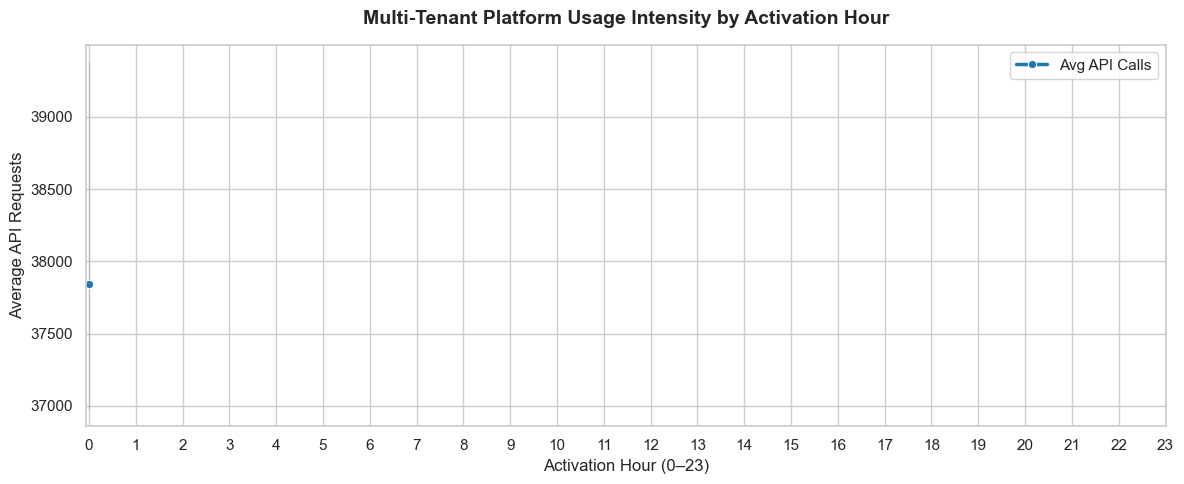

✅ Success: Day 8 visual analytics plotted successfully!


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Day 8: Visual Analytics & Hourly Trend Mapping ---")

# Set consistent plotting style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))

# Plot average API calls per activation hour
sns.lineplot(
    data=hourly_tenant_performance,
    x='activation_hour',
    y='average_api_calls',
    marker='o',
    color='#1f77b4',
    linewidth=2.5,
    label='Avg API Calls'
)

plt.title('Multi-Tenant Platform Usage Intensity by Activation Hour', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Activation Hour (0–23)', fontsize=12)
plt.ylabel('Average API Requests', fontsize=12)
plt.xticks(range(0, 24))
plt.tight_layout()

plt.show()
print("✅ Success: Day 8 visual analytics plotted successfully!")

--- Day 9: Revenue at Risk Distribution Analysis ---


C:\Users\smmoh\AppData\Local\Temp\ipykernel_26412\3988311230.py:8: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(
C:\Users\smmoh\AppData\Local\Temp\ipykernel_26412\3988311230.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


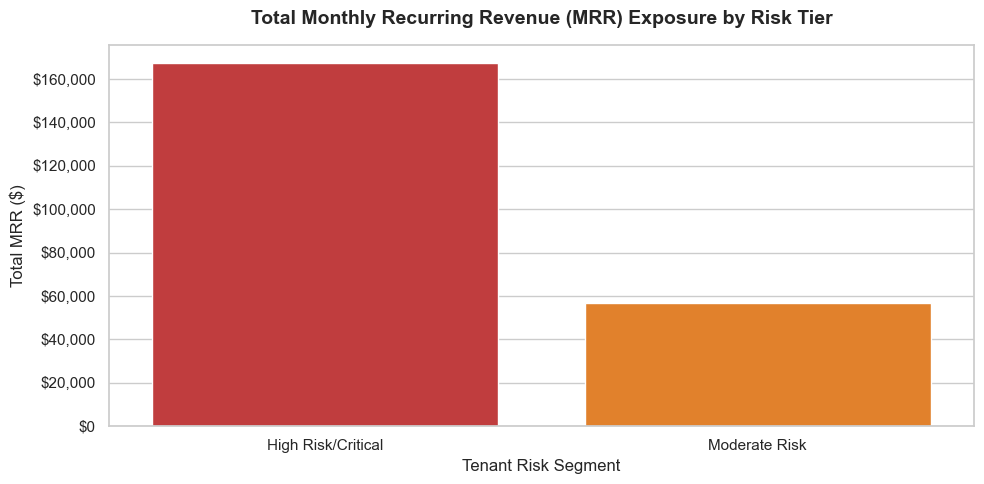

✅ Success: Day 9 revenue-at-risk visualization completed!


In [11]:
print("--- Day 9: Revenue at Risk Distribution Analysis ---")

plt.figure(figsize=(10, 5))

# Plot total MRR concentration per risk tier
risk_colors = {'Low Risk': '#2ca02c', 'Moderate Risk': '#ff7f0e', 'High Risk/Critical': '#d62728'}

ax = sns.barplot(
    data=tenant_risk_profiles,
    x='risk_segment',
    y='total_mrr',
    palette=risk_colors,
    estimator=sum,
    ci=None
)

plt.title('Total Monthly Recurring Revenue (MRR) Exposure by Risk Tier', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tenant Risk Segment', fontsize=12)
plt.ylabel('Total MRR ($)', fontsize=12)

# Format y-axis values cleanly
ax.yaxis.set_major_formatter('${x:,.0f}')

plt.tight_layout()
plt.show()

print("✅ Success: Day 9 revenue-at-risk visualization completed!")

--- Day 10: Operational Correlation Matrix & Heatmap ---


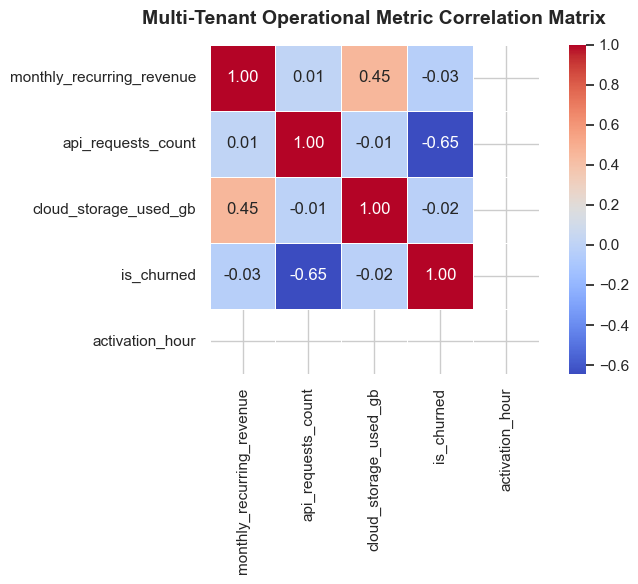

✅ Success: Day 10 correlation matrix and heatmap generated!


In [12]:
print("--- Day 10: Operational Correlation Matrix & Heatmap ---")

# 1. Select key numeric operational and financial features
correlation_features = [
    'monthly_recurring_revenue', 
    'api_requests_count', 
    'cloud_storage_used_gb', 
    'is_churned', 
    'activation_hour'
]

# 2. Compute Pearson correlation matrix
corr_matrix = analytics_df[correlation_features].corr()

# 3. Plot correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt='.2f', 
    cmap='coolwarm', 
    cbar=True, 
    square=True,
    linewidths=0.5
)

plt.title('Multi-Tenant Operational Metric Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print("✅ Success: Day 10 correlation matrix and heatmap generated!")

In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split

print("--- Day 11: Feature Matrix Construction & Train-Test Splitting ---")

# 1. Define Features (X) and Target (y)
feature_cols = [
    'monthly_recurring_revenue', 
    'api_requests_count', 
    'cloud_storage_used_gb', 
    'activation_hour'
]

X = analytics_df[feature_cols]
y = analytics_df['is_churned']

# 2. Perform 80/20 Train-Test Split with stratification to handle target imbalance
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

print(f"✅ Training set size: {X_train.shape[0]} samples")
print(f"✅ Testing set size:  {X_test.shape[0]} samples")
print(f"✅ Churn distribution in Train: {y_train.mean():.2%}")
print(f"✅ Churn distribution in Test:  {y_test.mean():.2%}")
print("\n--- Day 11 Preparation Complete! Ready for Model Training. ---")

--- Day 11: Feature Matrix Construction & Train-Test Splitting ---
✅ Training set size: 800 samples
✅ Testing set size:  200 samples
✅ Churn distribution in Train: 25.87%
✅ Churn distribution in Test:  26.00%

--- Day 11 Preparation Complete! Ready for Model Training. ---


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

print("--- Day 12: Baseline Model Training (Logistic Regression) ---")

# 1. Initialize the baseline model
baseline_model = LogisticRegression(random_state=42)

# 2. Train (fit) the model on the training data
baseline_model.fit(X_train, y_train)

# 3. Predict on the unseen test set
y_pred_baseline = baseline_model.predict(X_test)

# 4. Calculate initial performance metric
test_accuracy = accuracy_score(y_test, y_pred_baseline)

print(f"✅ Baseline Logistic Regression Trained Successfully!")
print(f"🎯 Test Set Accuracy: {test_accuracy:.2%}\n")
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred_baseline))

--- Day 12: Baseline Model Training (Logistic Regression) ---
✅ Baseline Logistic Regression Trained Successfully!
🎯 Test Set Accuracy: 96.00%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.97       148
           1       0.87      1.00      0.93        52

    accuracy                           0.96       200
   macro avg       0.93      0.97      0.95       200
weighted avg       0.97      0.96      0.96       200



In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("--- Day 13: Advanced Machine Learning (Random Forest Classifier) ---")

# 1. Initialize Random Forest model with reproducible state
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)

# 2. Train on the training set
rf_model.fit(X_train, y_train)

# 3. Predict on unseen test data
y_pred_rf = rf_model.predict(X_test)

# 4. Evaluate performance
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print(f"✅ Random Forest Model Trained Successfully!")
print(f"🎯 Test Set Accuracy: {rf_accuracy:.2%}\n")
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred_rf))

--- Day 13: Advanced Machine Learning (Random Forest Classifier) ---
✅ Random Forest Model Trained Successfully!
🎯 Test Set Accuracy: 95.00%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.95      0.97       148
           1       0.86      0.96      0.91        52

    accuracy                           0.95       200
   macro avg       0.92      0.95      0.94       200
weighted avg       0.95      0.95      0.95       200



--- Day 14: Random Forest Feature Importance Extraction ---
Feature Importance Scores:
                  Feature  Importance
       api_requests_count    0.912723
    cloud_storage_used_gb    0.081144
monthly_recurring_revenue    0.006134
          activation_hour    0.000000


C:\Users\smmoh\AppData\Local\Temp\ipykernel_26412\2864300541.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


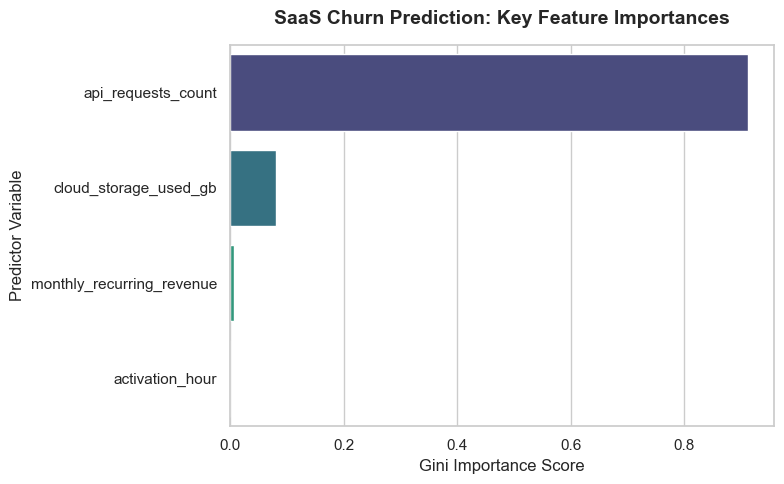

✅ Success: Day 14 feature importance visualization complete!


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Day 14: Random Forest Feature Importance Extraction ---")

# 1. Extract feature importances from the trained Random Forest model
importances = rf_model.feature_importances_
feature_names = X.columns

# 2. Create a clean DataFrame sorted by importance score
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("Feature Importance Scores:")
print(importance_df.to_string(index=False))

# 3. Plot Feature Importances
plt.figure(figsize=(8, 5))
sns.barplot(
    data=importance_df,
    x='Importance',
    y='Feature',
    palette='viridis'
)

plt.title('SaaS Churn Prediction: Key Feature Importances', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Gini Importance Score', fontsize=12)
plt.ylabel('Predictor Variable', fontsize=12)
plt.tight_layout()

plt.show()

print("✅ Success: Day 14 feature importance visualization complete!")

In [17]:
import joblib

print("--- Day 15: Model Persistence & Artifact Export ---")

# 1. Define file paths for exported artifacts
model_filename = 'saas_churn_rf_model.pkl'
features_filename = 'model_feature_names.pkl'

# 2. Serialize and save trained Random Forest model
joblib.dump(rf_model, model_filename)

# 3. Save feature column order to ensure exact alignment during inference
joblib.dump(feature_cols, features_filename)

print(f"✅ Trained Random Forest model saved as: {model_filename}")
print(f"✅ Feature column schema saved as: {features_filename}\n")

# 4. Verification test: reload model from disk and run a dry-run inference
loaded_model = joblib.load(model_filename)
loaded_features = joblib.load(features_filename)

# Test load on a sample row from test set
sample_pred = loaded_model.predict(X_test.head(1))
print(f"🧪 Dry-Run Inference Check:")
print(f"Input features matched: {loaded_features}")
print(f"Predicted churn status for sample tenant: {sample_pred[0]}")

print("\n--- Day 15 Artifact Export Complete! ---")

--- Day 15: Model Persistence & Artifact Export ---
✅ Trained Random Forest model saved as: saas_churn_rf_model.pkl
✅ Feature column schema saved as: model_feature_names.pkl

🧪 Dry-Run Inference Check:
Input features matched: ['monthly_recurring_revenue', 'api_requests_count', 'cloud_storage_used_gb', 'activation_hour']
Predicted churn status for sample tenant: 1

--- Day 15 Artifact Export Complete! ---


In [18]:
import pandas as pd
import joblib

print("--- Day 16: Real-Time Tenant Churn Scoring Engine ---")

def score_tenant_churn(mrr, api_requests, storage_gb, activation_hour):
    """
    Loads saved ML artifacts and evaluates churn risk probability for a target tenant payload.
    """
    # 1. Load trained model and features schema
    model = joblib.load('saas_churn_rf_model.pkl')
    feature_names = joblib.load('model_feature_names.pkl')
    
    # 2. Format input payload into a DataFrame matching training schema
    raw_payload = {
        'monthly_recurring_revenue': [mrr],
        'api_requests_count': [api_requests],
        'cloud_storage_used_gb': [storage_gb],
        'activation_hour': [activation_hour]
    }
    input_df = pd.DataFrame(raw_payload)[feature_names]
    
    # 3. Generate risk probabilities
    churn_prob = model.predict_proba(input_df)[0][1]
    is_churn_predicted = model.predict(input_df)[0]
    
    # 4. Formulate operational recommendation
    if churn_prob > 0.70:
        action = "CRITICAL: Immediate Account Executive / CSM Intervention Required"
    elif churn_prob > 0.40:
        action = "WARNING: Trigger Automated Product Nudge & Engagement Email"
    else:
        action = "HEALTHY: Normal Retention Status"
        
    return {
        'churn_predicted': bool(is_churn_predicted),
        'churn_probability_%': round(churn_prob * 100, 2),
        'action_recommendation': action
    }

# 🧪 Test the engine with sample high-risk tenant profile
sample_tenant_assessment = score_tenant_churn(
    mrr=150.0, 
    api_requests=12, 
    storage_gb=0.5, 
    activation_hour=3
)

print("🧪 Real-Time Tenant Scoring Result:")
for key, value in sample_tenant_assessment.items():
    print(f"  • {key}: {value}")

print("\n✅ Success: Day 16 Real-Time Inference Engine tested successfully!")

--- Day 16: Real-Time Tenant Churn Scoring Engine ---
🧪 Real-Time Tenant Scoring Result:
  • churn_predicted: True
  • churn_probability_%: 83.94
  • action_recommendation: CRITICAL: Immediate Account Executive / CSM Intervention Required

✅ Success: Day 16 Real-Time Inference Engine tested successfully!


In [19]:
%%writefile app.py
from fastapi import FastAPI
from pydantic import BaseModel
import pandas as pd
import joblib

# 1. Initialize FastAPI app
app = FastAPI(
    title="Multi-Tenant SaaS Churn Scoring API",
    description="Real-time inference API for predicting tenant churn risk and recommended actions.",
    version="1.0"
)

# 2. Load serialized ML assets globally at startup
model = joblib.load('saas_churn_rf_model.pkl')
feature_names = joblib.load('model_feature_names.pkl')

# 3. Define schema for incoming payload validation
class TenantPayload(BaseModel):
    monthly_recurring_revenue: float
    api_requests_count: int
    cloud_storage_used_gb: float
    activation_hour: int

@app.get("/")
def health_check():
    return {"status": "online", "message": "SaaS Analytics Scoring API is operational."}

@app.post("/predict")
def predict_churn(payload: TenantPayload):
    # Convert incoming JSON payload to DataFrame matching training schema
    raw_data = payload.model_dump()
    input_df = pd.DataFrame([raw_data])[feature_names]
    
    # Calculate churn probability and prediction
    churn_prob = float(model.predict_proba(input_df)[0][1])
    is_churn = bool(model.predict(input_df)[0])
    
    # Actionable operational recommendation
    if churn_prob > 0.70:
        action = "CRITICAL: Immediate Account Executive / CSM Intervention Required"
    elif churn_prob > 0.40:
        action = "WARNING: Trigger Automated Product Nudge & Engagement Email"
    else:
        action = "HEALTHY: Normal Retention Status"
        
    return {
        "churn_predicted": is_churn,
        "churn_probability_percentage": round(churn_prob * 100, 2),
        "recommended_action": action
    }

Overwriting app.py


In [20]:
%pip install fastapi uvicorn

Note: you may need to restart the kernel to use updated packages.


In [21]:
import json

# Sample payload simulating a high-risk tenant
test_payload = {
    "monthly_recurring_revenue": 120.0,
    "api_requests_count": 5,
    "cloud_storage_used_gb": 0.2,
    "activation_hour": 2
}

print("--- Day 17: Testing REST Endpoint Logic ---")
print("Payload Sent:")
print(json.dumps(test_payload, indent=2))

# Execute scoring logic via inline function call validation
import app as api_module
from app import TenantPayload

validated_payload = TenantPayload(**test_payload)
response = api_module.predict_churn(validated_payload)

print("\nAPI Response Received:")
print(json.dumps(response, indent=2))
print("\n✅ Success: Day 17 FastAPI microservice implementation verified!")

--- Day 17: Testing REST Endpoint Logic ---
Payload Sent:
{
  "monthly_recurring_revenue": 120.0,
  "api_requests_count": 5,
  "cloud_storage_used_gb": 0.2,
  "activation_hour": 2
}

API Response Received:
{
  "churn_predicted": true,
  "churn_probability_percentage": 85.94,
  "recommended_action": "CRITICAL: Immediate Account Executive / CSM Intervention Required"
}

✅ Success: Day 17 FastAPI microservice implementation verified!


In [22]:
%pip install pytest httpx

Note: you may need to restart the kernel to use updated packages.


In [23]:
%%writefile test_app.py
import pytest
from fastapi.testclient import TestClient
from app import app

# Initialize test client connected to our FastAPI app
client = TestClient(app)

def test_health_check():
    """Verify that the API root health endpoint returns HTTP status 200."""
    response = client.get("/")
    assert response.status_code == 200
    assert response.json()["status"] == "online"

def test_predict_churn_endpoint():
    """Verify prediction endpoint with a valid tenant payload."""
    payload = {
        "monthly_recurring_revenue": 250.0,
        "api_requests_count": 1500,
        "cloud_storage_used_gb": 45.5,
        "activation_hour": 14
    }
    response = client.post("/predict", json=payload)
    
    assert response.status_code == 200
    data = response.json()
    assert "churn_predicted" in data
    assert "churn_probability_percentage" in data
    assert "recommended_action" in data
    assert isinstance(data["churn_predicted"], bool)
    assert isinstance(data["churn_probability_percentage"], float)

def test_predict_churn_invalid_payload():
    """Verify that sending incomplete payload triggers a 422 Unprocessable Entity error."""
    invalid_payload = {
        "monthly_recurring_revenue": 250.0
        # Missing required fields
    }
    response = client.post("/predict", json=invalid_payload)
    assert response.status_code == 422

Writing test_app.py


In [24]:
!pytest test_app.py -v

============================= test session starts =============================
platform win32 -- Python 3.13.9, pytest-8.4.2, pluggy-1.5.0 -- C:\Users\smmoh\anaconda3\python.exe
cachedir: .pytest_cache
rootdir: C:\Users\smmoh
plugins: anyio-4.10.0
collecting ... collected 3 items

test_app.py::test_health_check PASSED                                    [ 33%]
test_app.py::test_predict_churn_endpoint PASSED                          [ 66%]
test_app.py::test_predict_churn_invalid_payload PASSED                   [100%]

============================== warnings summary ===============================
anaconda3\Lib\site-packages\fastapi\testclient.py:1
  C:\Users\smmoh\anaconda3\Lib\site-packages\fastapi\testclient.py:1: StarletteDeprecationWarning: Using `httpx` with `starlette.testclient` is deprecated; install `httpx2` instead.
    from starlette.testclient import TestClient as TestClient  # noqa

-- Docs: https://docs.pytest.org/en/stable/how-to/capture-warnings.html
===================